In [ ]:

import numpy as np
import pandas as pd
import os
import argparse
from tqdm import tqdm

def npz_to_df_csv(npz_file):
        data = np.load(npz_file, allow_pickle=True)
        df = pd.DataFrame(data['params'], columns=data['param_names'])
        df.to_csv(npz_file.replace(".npz", ".csv"), index=False)
        print(df.head())

npz_file="/data/home/zzh/data/Dataset_Filted/Experiment/2024/20240101_no_muon_cut_1e11_V04_dataset_fastcode.npz"
# npz_to_df_csv(npz_file)


In [43]:
import numpy as np
import pandas as pd
import uproot
from xgboost import XGBRegressor

# --- 1. 配置参数 ---
BASE_PATH = "/data/home/zzh/data/Dataset_Filted/CosmicRay"
FILES = {
    "proton": "QF_Proton_addweight_rho_2.5e13_5.0e17_V3.root",
    "he":     "QF_He_addweight_rho_2.5e13_5.0e17_V3.root",
    "cno":    "QF_CNO_addweight_rho_2.5e13_5.0e17_V3.root",
    "fe":     "QF_Fe_addweight_rho_2.5e13_5.0e17_V3.root",
    "mgalsi": "QF_MgAlSi_addweight_rho_2.5e13_5.0e17_V3.root"
}

CUTS = (
    "rec_Eage > 0 and Redge > 0 and NuW3 > 0 and NpE3 > 250 "
    "and @theta_cut_low < rec_theta < @theta_cut_high"
)

# 阈值变量
r_cut_low, r_cut_high = 320, 420
theta_cut_low, theta_cut_high = np.deg2rad([10, 30])
log10TeV_low=2.76; log10TeV_high=3.16

# --- 2. 能量修正模型 ---
model = XGBRegressor();model._estimator_type = "regressor"
model.load_model("/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json")
import json
        
# 加载线性参数
with open("/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json", 'r') as f:
    lp = json.load(f)
intercept  = lp["intercept"]
coef_NuW3  = lp["coef"][0]
coef_theta = lp["coef"][1]
# --- 3. 核心处理函数 ---
def process_cosmic_ray(name, filename):
    with uproot.open(f"{BASE_PATH}/{filename}") as f:
        # 读取数据
        branches = ["E", "theta", "phi", "corex", "corey", "rec_x", "rec_y", 
                    "rec_theta", "rec_phi", "rec_Eage", "Redge", "NpE3", "NuM1", "NuW3", "weightGaisser", "weightHorandol"]
        df = f["Rec"].arrays(branches, library="pd")
        
        print(f"Processing {name}: Entries={len(df)}, Weights={df['weightGaisser'].sum():.2e}")

        # 1. 基础物理筛选
        df = df.query(CUTS).copy()
        
        # 2. 计算特征量
        df["R_ue"] = np.log10((1e-4 + df["NuM1"]) / (df["NpE3"]))
        df["r"] = np.hypot(df['rec_x'], df['rec_y']) # 比 sqrt(x^2+y^2) 更快
        
        # 3. 半径进一步筛选
        df = df[(df["r"] > r_cut_low) & (df["r"] < r_cut_high)]
        df['NuW3'] = np.log10(df['NuW3'])
        # 4. XGBoost 能量修正
        features = df[["NuW3", "rec_theta"]].values
        df["recE"] = model.predict(features) + intercept + coef_NuW3 * df['NuW3'] + coef_theta * df['rec_theta']
        print(f"     Finished {name}: Remaining Entries={len(df)}")
        return df[(df['recE']>log10TeV_low) & (df['recE']<log10TeV_high)]

# --- 4. 批量执行 ---
dfs = {name: process_cosmic_ray(name, path) for name, path in FILES.items()}
# 如果你需要解包到独立变量（虽然推荐直接用字典 dfs['proton']）
proton_df, he_df, cno_df, fe_df, mgalsi_df = dfs.values()
df_all_components = pd.concat(dfs.values(), ignore_index=True)
df_all_components['Eage'] = df_all_components['rec_Eage'] 




Processing proton: Entries=14217778, Weights=1.90e+02
     Finished proton: Remaining Entries=767187
Processing he: Entries=14210418, Weights=2.03e+02
     Finished he: Remaining Entries=525865
Processing cno: Entries=14218958, Weights=7.65e+01
     Finished cno: Remaining Entries=398519
Processing fe: Entries=14217887, Weights=7.40e+01
     Finished fe: Remaining Entries=330377
Processing mgalsi: Entries=14220016, Weights=3.57e+01
     Finished mgalsi: Remaining Entries=364106


In [ ]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


def give_bkg_mc_weights_gaisser(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/exposure_Gaisser.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    
    pr_df['gaisser_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['gaisser_weight']=pr_df['gaisser_weight']/86400
    # print(f"======> Total expected background MC events after weighting: {pr_df['gaisser_weight'].sum()} ======")
    return pr_df


r_cut_low, r_cut_high = 320, 420
theta_cut_low, theta_cut_high = np.deg2rad([10, 30])
log10TeV_low=2.76; log10TeV_high=3.16


# mc_data=np.load("/data/home/zzh/data/Dataset_Filted/Simulation/1e11_V04/Proton_combined_filted_1e11_V04_dataset_fastcode.npz", allow_pickle=True)
# mc_hitsE=mc_data['hitsE'];mc_hitsM = mc_data['hitsM']; mc_params = mc_data['params']; mc_param_names = mc_data['param_names'];print(f'Loaded {len(mc_data["hitsE"])}'); del mc_data
# mc_df = pd.DataFrame(mc_params, columns=mc_param_names)
# mc_df = energy_rec(mc_df)
# mc_df['rec_x']= pd.to_numeric(mc_df['rec_x'], errors='coerce'); mc_df['rec_y'] = pd.to_numeric(mc_df['rec_y'], errors='coerce'); mc_df['rec_r']=np.sqrt(mc_df['rec_x']**2 + mc_df['rec_y']**2)
# mc_df = give_bkg_mc_weights_gaisser(mc_df)
# ==========================================    
data=np.load("/data/home/zzh/data/Dataset_Filted/Experiment/2024/2024_Rue_19_cut_1e11_V04_361days_dataset_fastcode.npz",allow_pickle=True)
hitsE=data['hitsE'];hitsM = data['hitsM']; params = data['params']; param_names = data['param_names'];print(f'Loaded {len(data["hitsE"])}'); del data
df = pd.DataFrame(params, columns=param_names)
df['rec_x'] = pd.to_numeric(df['rec_x'], errors='coerce'); df['rec_y'] = pd.to_numeric(df['rec_y'], errors='coerce'); df['rec_r']=np.sqrt(df['rec_x']**2 + df['rec_y']**2)

exp_Rue_df = df[(df['rec_r']>r_cut_low) & (df['rec_r']<r_cut_high) & (df['rec_theta'] > theta_cut_low) & (df['rec_theta'] < theta_cut_high)]
print(f"\n Exp data: {len(exp_Rue_df)} events")
# ==========================================    
one_day_data=pd.read_csv("/data/home/zzh/data/Dataset_Filted/Experiment/2024/20240101_no_muon_cut_1e11_V04_dataset_fastcode.csv")
print(f'\n Loaded {len(one_day_data)}')
one_day_data['rec_x']= pd.to_numeric(one_day_data['rec_x'], errors='coerce'); one_day_data['rec_y'] = pd.to_numeric(one_day_data['rec_y'], errors='coerce'); one_day_data['rec_r']=np.sqrt(one_day_data['rec_x']**2 + one_day_data['rec_y']**2)
one_day_data = energy_rec(one_day_data)
one_day_df = one_day_data[(one_day_data['rec_r']>r_cut_low) & (one_day_data['rec_r']<r_cut_high) & (one_day_data['rec_theta'] > theta_cut_low) & (one_day_data['rec_theta'] < theta_cut_high)]
print(f"One day data: {len(one_day_df)} events")

def energy_rec(df):
    df['NuW3'] = pd.to_numeric(df['NuW3'], errors='coerce')
    df['NuW3'] = np.log10(df['NuW3'])
    # 4. XGBoost 能量修正
    features = df[["NuW3", "rec_theta"]].values
    df["recE"] = model.predict(features) + intercept + coef_NuW3 * df['NuW3'] + coef_theta * df['rec_theta']
    return df




# Index(['label', 'weight', 'R_ue', 'R_mean', 'Eage', 'compactness', 'pincness',
#        'recE', 'rec_x', 'rec_y', 'rec_theta', 'rec_phi', 'NpE3', 'NuM1',
#        'NuM2', 'NuM3', 'NuM4', 'NuM5', 'trueE', 'core_x', 'core_y', 'theta',
#        'phi', 'dr', 'NuW3', 'NuW2'],
#       dtype='object')


Loaded 64308
Loaded 161654

 Exp data: 10585 events

 Loaded 275605
One day data: 8766 events


In [45]:
one_day_df = energy_rec(one_day_df)
one_day_df['recE'].min()

2.7331443298605738

------------------------------
Processing Experimental Data...
Exp Data: 275605 -> 3531 events (after cuts)
------------------------------
Merging MC Components...
Total MC Events: 37908
Total MC Flux Weight: 4.78e-02
------------------------------
Calculating Systematics Shifts (Data - MC)...

[recE Shift]
  Mean Data: 3.0447
  Mean MC  : 3.0450
  Shift (Data-MC): -0.0003
  Recommended UNC_E: 0.0003 (or conservative 0.05)

[R_ue Shift]
  Mean Data: -1.0927
  Mean MC  : -1.0752
  Shift (Data-MC): -0.0175
  Recommended UNC_RUE: 0.0175

[Eage Shift]
  Mean Data: 1.2492
  Mean MC  : 1.2221
  Shift (Data-MC): 0.0271, 0.0269
  Recommended UNC_EAGE: 0.0271

[rec_theta Shift]
  Mean Data: 0.3634
  Mean MC  : 0.3650
  Shift (Data-MC): -0.0016
  Recommended UNC_THETA: 0.0016


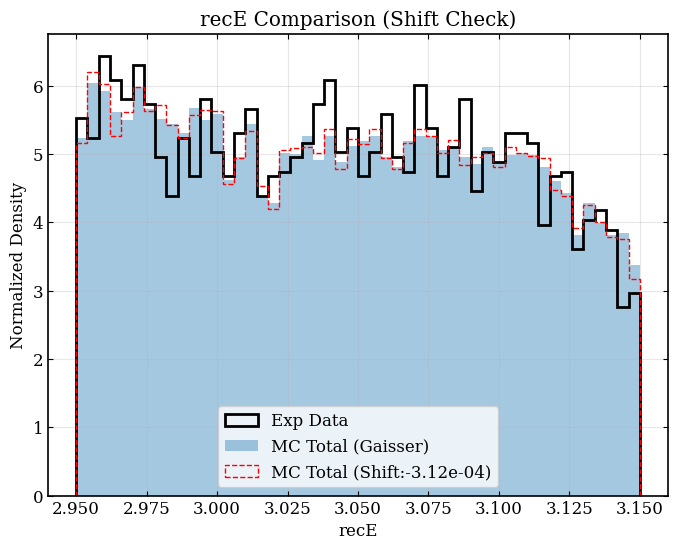

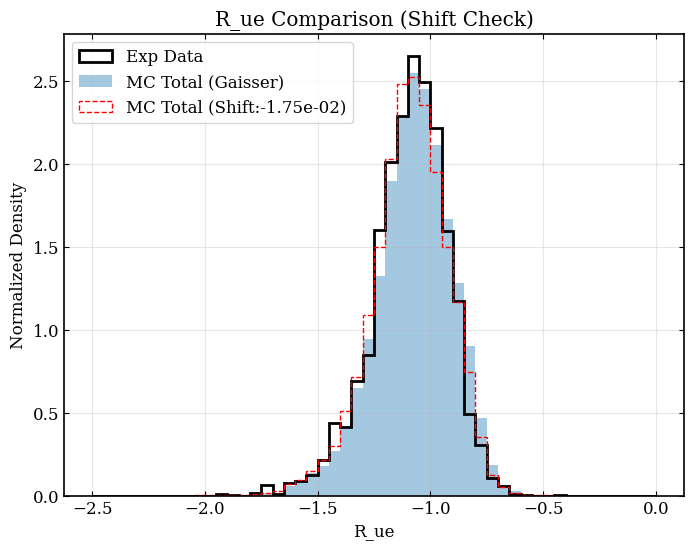

In [48]:
import numpy as np
import pandas as pd



r_cut_low, r_cut_high = 320, 420
theta_cut_low, theta_cut_high = np.deg2rad([10, 30])
log10TeV_low=2.95; log10TeV_high=3.15

CUTS_QUERY = (
    "rec_Eage > 0 and NpE3 > 250 "
    "and @theta_cut_low < rec_theta < @theta_cut_high "
    "and @log10TeV_low < recE < @log10TeV_high"
)
CUTS_QUERY_exp = (
    "Eage > 0 and NpE3 > 250 "
    "and @theta_cut_low < rec_theta < @theta_cut_high "
    "and @log10TeV_low < recE < @log10TeV_high"
)




# ==========================================
# 1. 处理实验数据 (Apply Same Cuts)
# ==========================================
print("-" * 30)
print("Processing Experimental Data...")

# 1. 复制一份以免修改原数据
exp_df = one_day_data.copy()
exp_df = energy_rec(exp_df)
# 2. 补充必要的几何变量 (如果 CSV 里没有 r)
# 假设 rec_x, rec_y 存在于 CSV 中
if 'r' not in exp_df.columns:
    exp_df["r"] = np.hypot(exp_df['rec_x'], exp_df['rec_y'])

# 3. 应用基础物理切选 (rec_Eage, Theta, etc.)
# 假设 CSV 列名与 MC 保持一致
before_cut = len(exp_df)
exp_df = exp_df.query(CUTS_QUERY_exp)

# 4. 应用半径切选
exp_df = exp_df[(exp_df["r"] > r_cut_low) & (exp_df["r"] < r_cut_high)]

# 5. 应用能量切选 (recE 已存在于 CSV)
exp_df = exp_df[(exp_df['recE'] > log10TeV_low) & (exp_df['recE'] < log10TeV_high)]

print(f"Exp Data: {before_cut} -> {len(exp_df)} events (after cuts)")

# ==========================================
# 2. 合并 MC 数据 (Weighted Concatenation)
# ==========================================
print("-" * 30)
print("Merging MC Components...")

# 将之前处理好的 5 个 DataFrame 合并
# 假设 dfs 是上一段代码生成的字典
mc_df_list = []
for name, df in dfs.items():
    temp_df = df.copy()
    temp_df['component'] = name  # 标记成分 (可选)
    mc_df_list.append(temp_df)

mc_total = pd.concat(mc_df_list, ignore_index=True)
# 筛选
mc_total = mc_total.query(CUTS_QUERY)
print(f"Total MC Events: {len(mc_total)}")
print(f"Total MC Flux Weight: {mc_total['weightGaisser'].sum():.2e}")

# ==========================================
# 3. 计算偏移量 (Shift Calculation)
# ==========================================
print("-" * 30)
print("Calculating Systematics Shifts (Data - MC)...")

def get_weighted_stats(values, weights=None, val_range=None):
    """计算加权均值"""
    if weights is None:
        weights = np.ones(len(values))
    # 如果提供了 val_range，可以先筛选出范围内的值和对应的权重
    if val_range is not None:
        mask = (values >= val_range[0]) & (values <= val_range[1])
        values_masked = values[mask]
        weights_masked = weights[mask]
    else:
        values_masked = values
        weights_masked = weights
    # 计算加权均值
    if np.sum(weights_masked) == 0:
        return np.nan, np.nan
    else:
        average = np.average(values_masked, weights=weights_masked)
        # 也可以计算加权标准差用于参考
        variance = np.average((values_masked - average)**2, weights=weights_masked)
        return average, np.sqrt(variance)


# --- A. 计算 recE 的偏移 ---
# Exp (无权重或权重为1)
mu_exp_E, std_exp_E = get_weighted_stats(exp_df['recE'])
# MC (使用 Gaisser 权重)
mu_mc_E, std_mc_E = get_weighted_stats(mc_total['recE'], mc_total['weightGaisser'])

diff_E = mu_exp_E - mu_mc_E
print(f"\n[recE Shift]")
print(f"  Mean Data: {mu_exp_E:.4f}")
print(f"  Mean MC  : {mu_mc_E:.4f}")
print(f"  Shift (Data-MC): {diff_E:.4f}") 
print(f"  Recommended UNC_E: {abs(diff_E):.4f} (or conservative {max(0.05, abs(diff_E)):.2f})")

# --- B. 计算 R_ue 的偏移 ---
# 注意：确保 Data 也是在 CR 区域 (Rue > -2)
# 代码逻辑中 exp_df 已经是 CR 数据了，但为了严谨，我们计算 Shift 时
# 最好限制 MC 也只看 Rue > -2 的部分 (Sideband Comparison)，或者看峰值位置
# 这里我们直接比较整体均值 (假设都在 Background Region)

# 如果想更严谨，取 -4 < Rue < -1.8 这种纯背景区计算
# 这里演示全范围计算（基于前面已经做过的筛选）
mu_exp_R, std_exp_R = get_weighted_stats(exp_df['R_ue'])
mu_mc_R, std_mc_R = get_weighted_stats(mc_total['R_ue'], mc_total['weightGaisser'])

diff_R = mu_exp_R - mu_mc_R
print(f"\n[R_ue Shift]")
print(f"  Mean Data: {mu_exp_R:.4f}")
print(f"  Mean MC  : {mu_mc_R:.4f}")
print(f"  Shift (Data-MC): {diff_R:.4f}")
print(f"  Recommended UNC_RUE: {abs(diff_R):.4f}")

# --- C. 计算 Eage 的偏移 ---
age_range = (0.9, 1.6)  # Eage 的合理范围
mu_exp_Eage, std_exp_Eage = get_weighted_stats(exp_df['Eage'], val_range=age_range)
mu_mc_Eage, std_mc_Eage = get_weighted_stats(mc_total['rec_Eage'], mc_total['weightGaisser'], val_range=age_range)
mu_mc_Eage_horandel, std_mc_Eage_horandel = get_weighted_stats(mc_total['rec_Eage'], mc_total['weightHorandol'], val_range=age_range)
diff_Eage = mu_exp_Eage - mu_mc_Eage
diff_Eage_horandel = mu_exp_Eage - mu_mc_Eage_horandel
print(f"\n[Eage Shift]")
print(f"  Mean Data: {mu_exp_Eage:.4f}")
print(f"  Mean MC  : {mu_mc_Eage:.4f}")
print(f"  Shift (Data-MC): {diff_Eage:.4f}, {diff_Eage_horandel:.4f}")
print(f"  Recommended UNC_EAGE: {abs(diff_Eage):.4f}")

# --- D. 计算 rec_theta 的偏移 ---
mu_exp_theta, std_exp_theta = get_weighted_stats(exp_df['rec_theta'])
mu_mc_theta, std_mc_theta = get_weighted_stats(mc_total['rec_theta'], mc_total['weightGaisser'])

diff_theta = mu_exp_theta - mu_mc_theta
print(f"\n[rec_theta Shift]")
print(f"  Mean Data: {mu_exp_theta:.4f}")
print(f"  Mean MC  : {mu_mc_theta:.4f}")
print(f"  Shift (Data-MC): {diff_theta:.4f}")
print(f"  Recommended UNC_THETA: {abs(diff_theta):.4f}")

# ==========================================
# 4. 可视化验证 (强烈建议)
# ==========================================
import matplotlib.pyplot as plt

def plot_comparison(var_name, bins, range_val, diff_shift=None ,log=False):
    plt.figure(figsize=(8, 6))
    
    var_name_mc_all = var_name
    if var_name == 'Eage':
        var_name_mc_all = 'rec_Eage'
    
    # Plot Exp (Density)
    plt.hist(exp_df[var_name], bins=bins, range=range_val, density=True,
             histtype='step', color='black', label='Exp Data', lw=2)
    
    # Plot MC (Density + Weighted)
    plt.hist(mc_total[var_name_mc_all], bins=bins, range=range_val, weights=mc_total['weightGaisser'],
             density=True, histtype='stepfilled', alpha=0.4, label='MC Total (Gaisser)')
    
    if diff_shift is not None:
        mc_total[f"{var_name_mc_all}_shifted"] = mc_total[var_name_mc_all] + diff_shift
        plt.hist(mc_total[f"{var_name_mc_all}_shifted"], bins=bins, range=range_val, weights=mc_total['weightGaisser'],
                 density=True, histtype='step', color='red', label=f'MC Total (Shift:{diff_shift:.2e})', lw=1, linestyle='--')
        
    
    plt.title(f"{var_name} Comparison (Shift Check)")
    plt.xlabel(var_name)
    plt.ylabel("Normalized Density")
    plt.legend()
    if log: plt.yscale('log')
    plt.grid(alpha=0.3)
    plt.show()

plot_comparison('recE', 50, (log10TeV_low, log10TeV_high), diff_shift=diff_E    )
plot_comparison('R_ue', 50, (-2.5, 0), diff_shift=diff_R)

# plot_comparison('Eage', 50, (0.9, 1.6), diff_shift=diff_Eage)
# plot_comparison('rec_theta', 50, (np.deg2rad(10), np.deg2rad(30)), diff_shift=diff_theta)

Plotting Data Evolution...
Saving figure to /data/home/zzh/Filt_Event/Note_Writing/figures/1e11_data_Rue_Stability_Eage.pdf ...


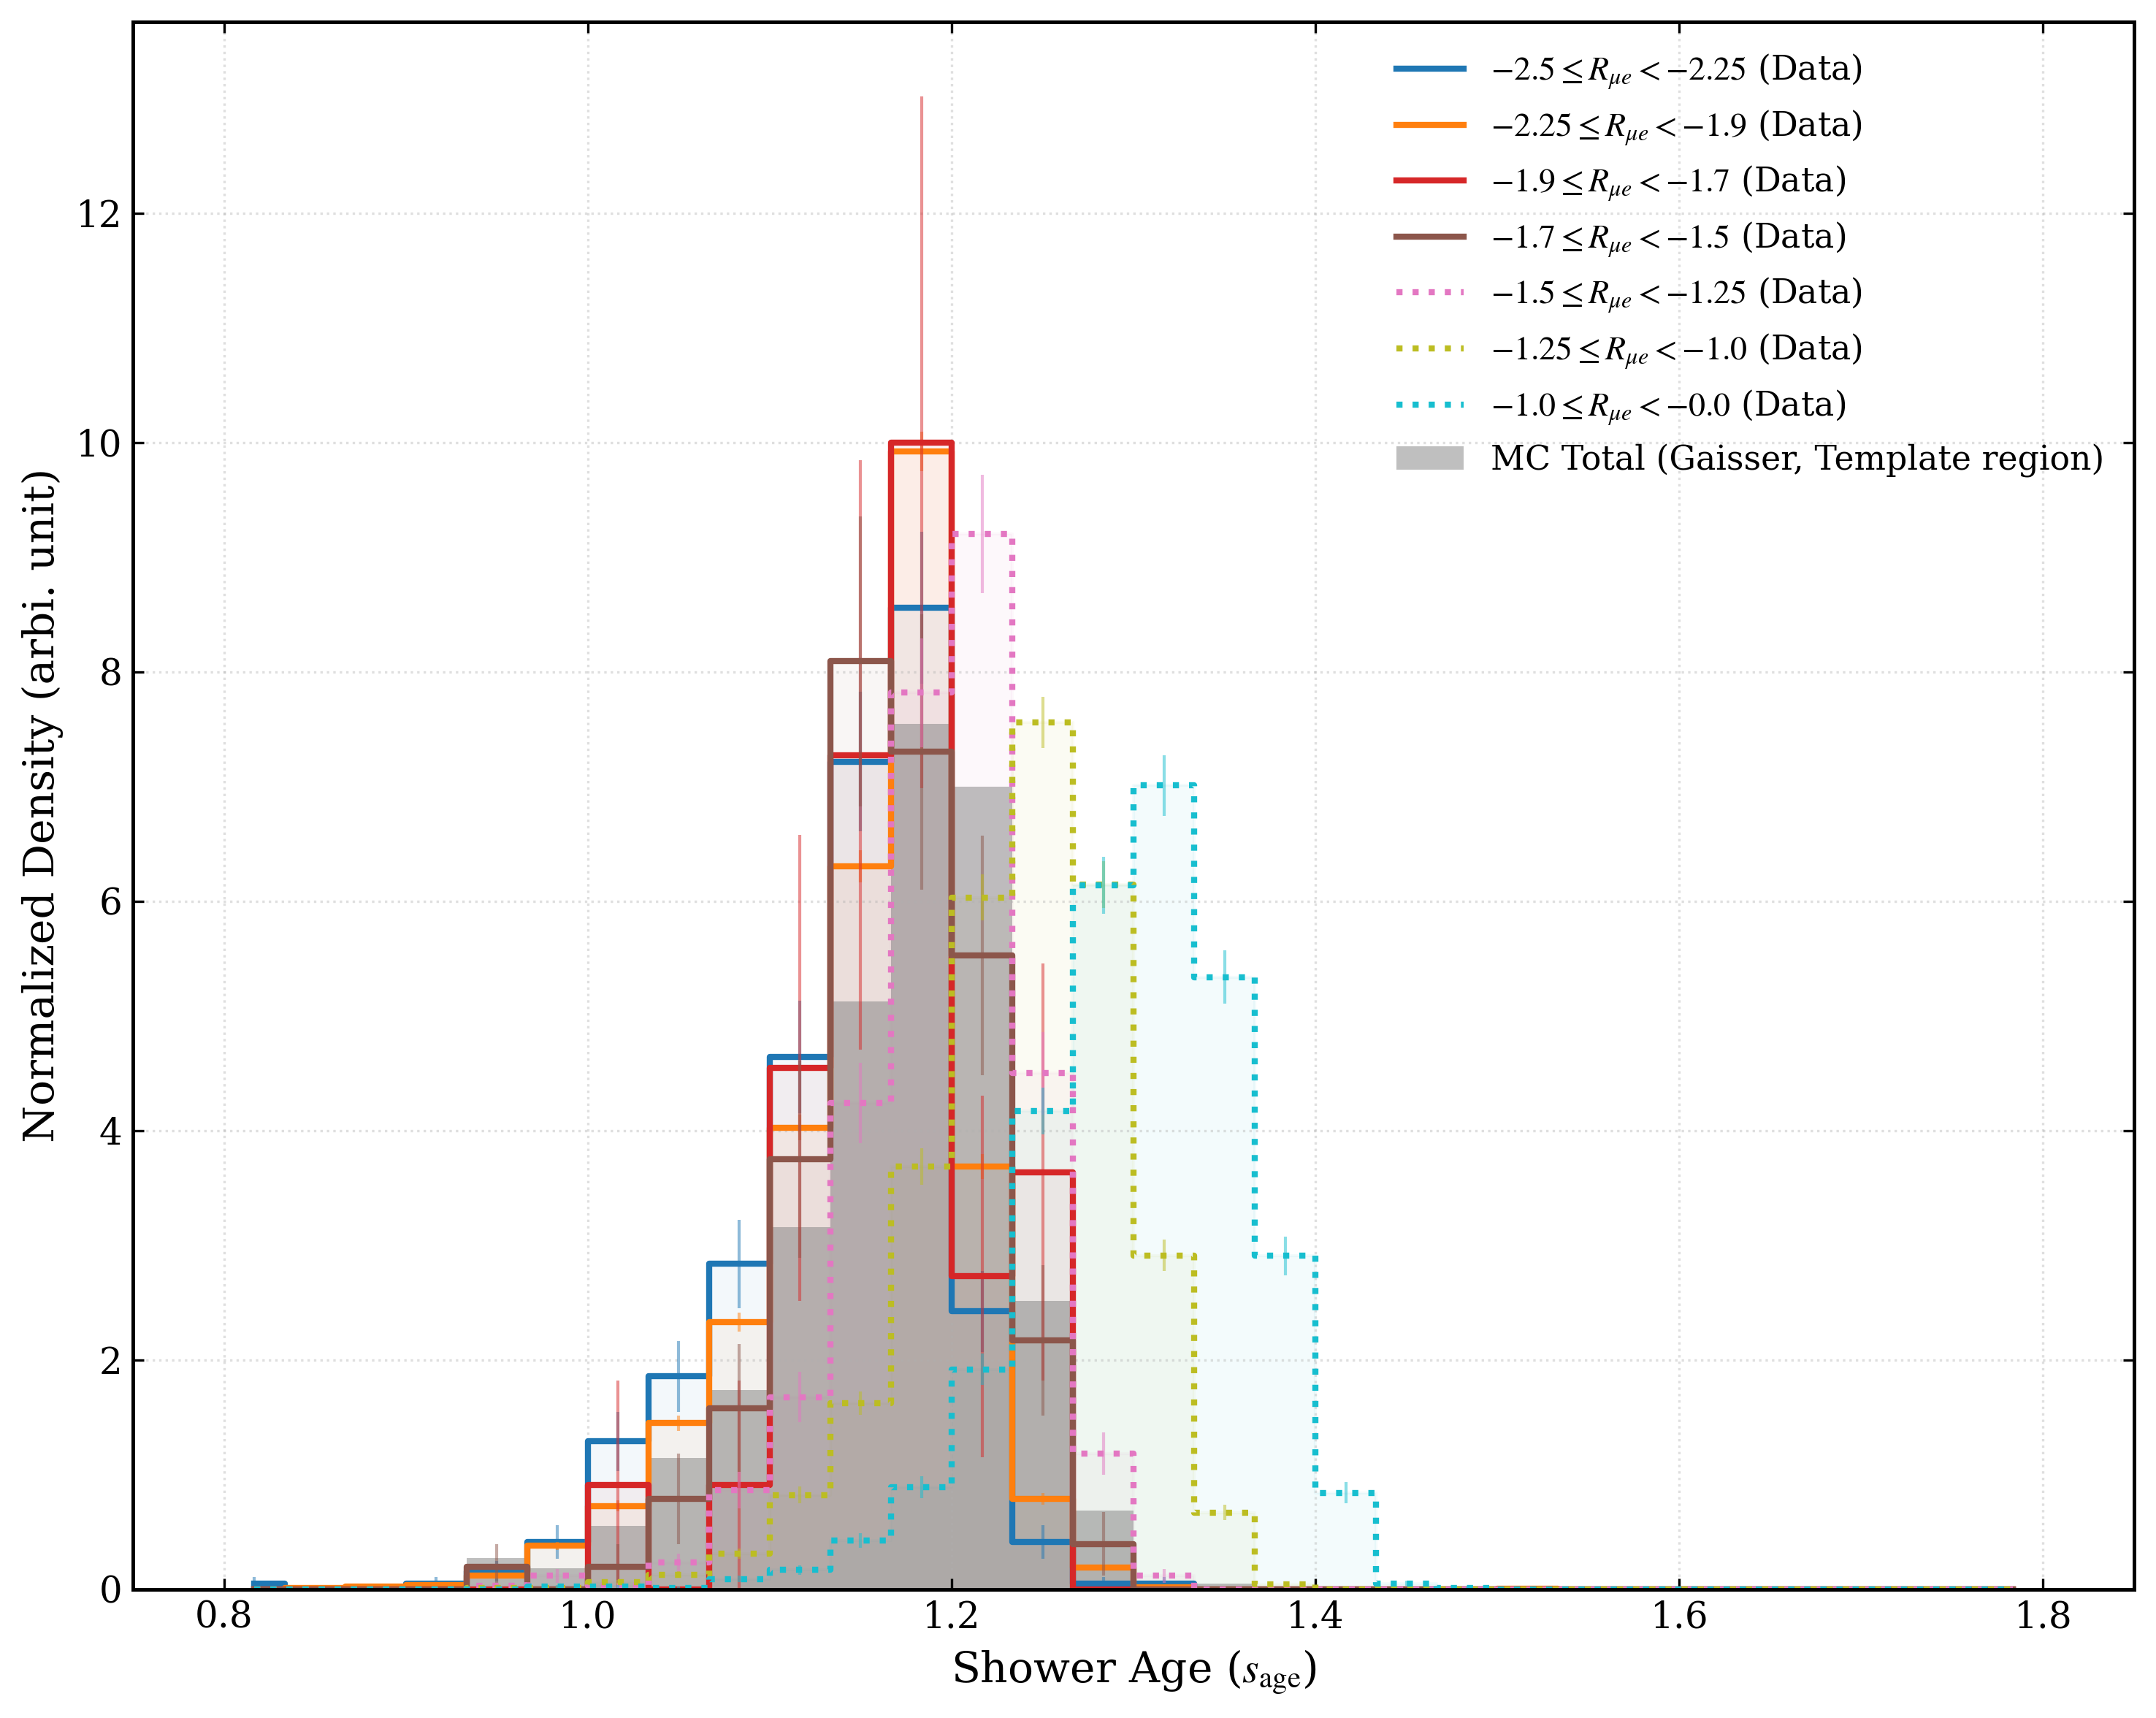

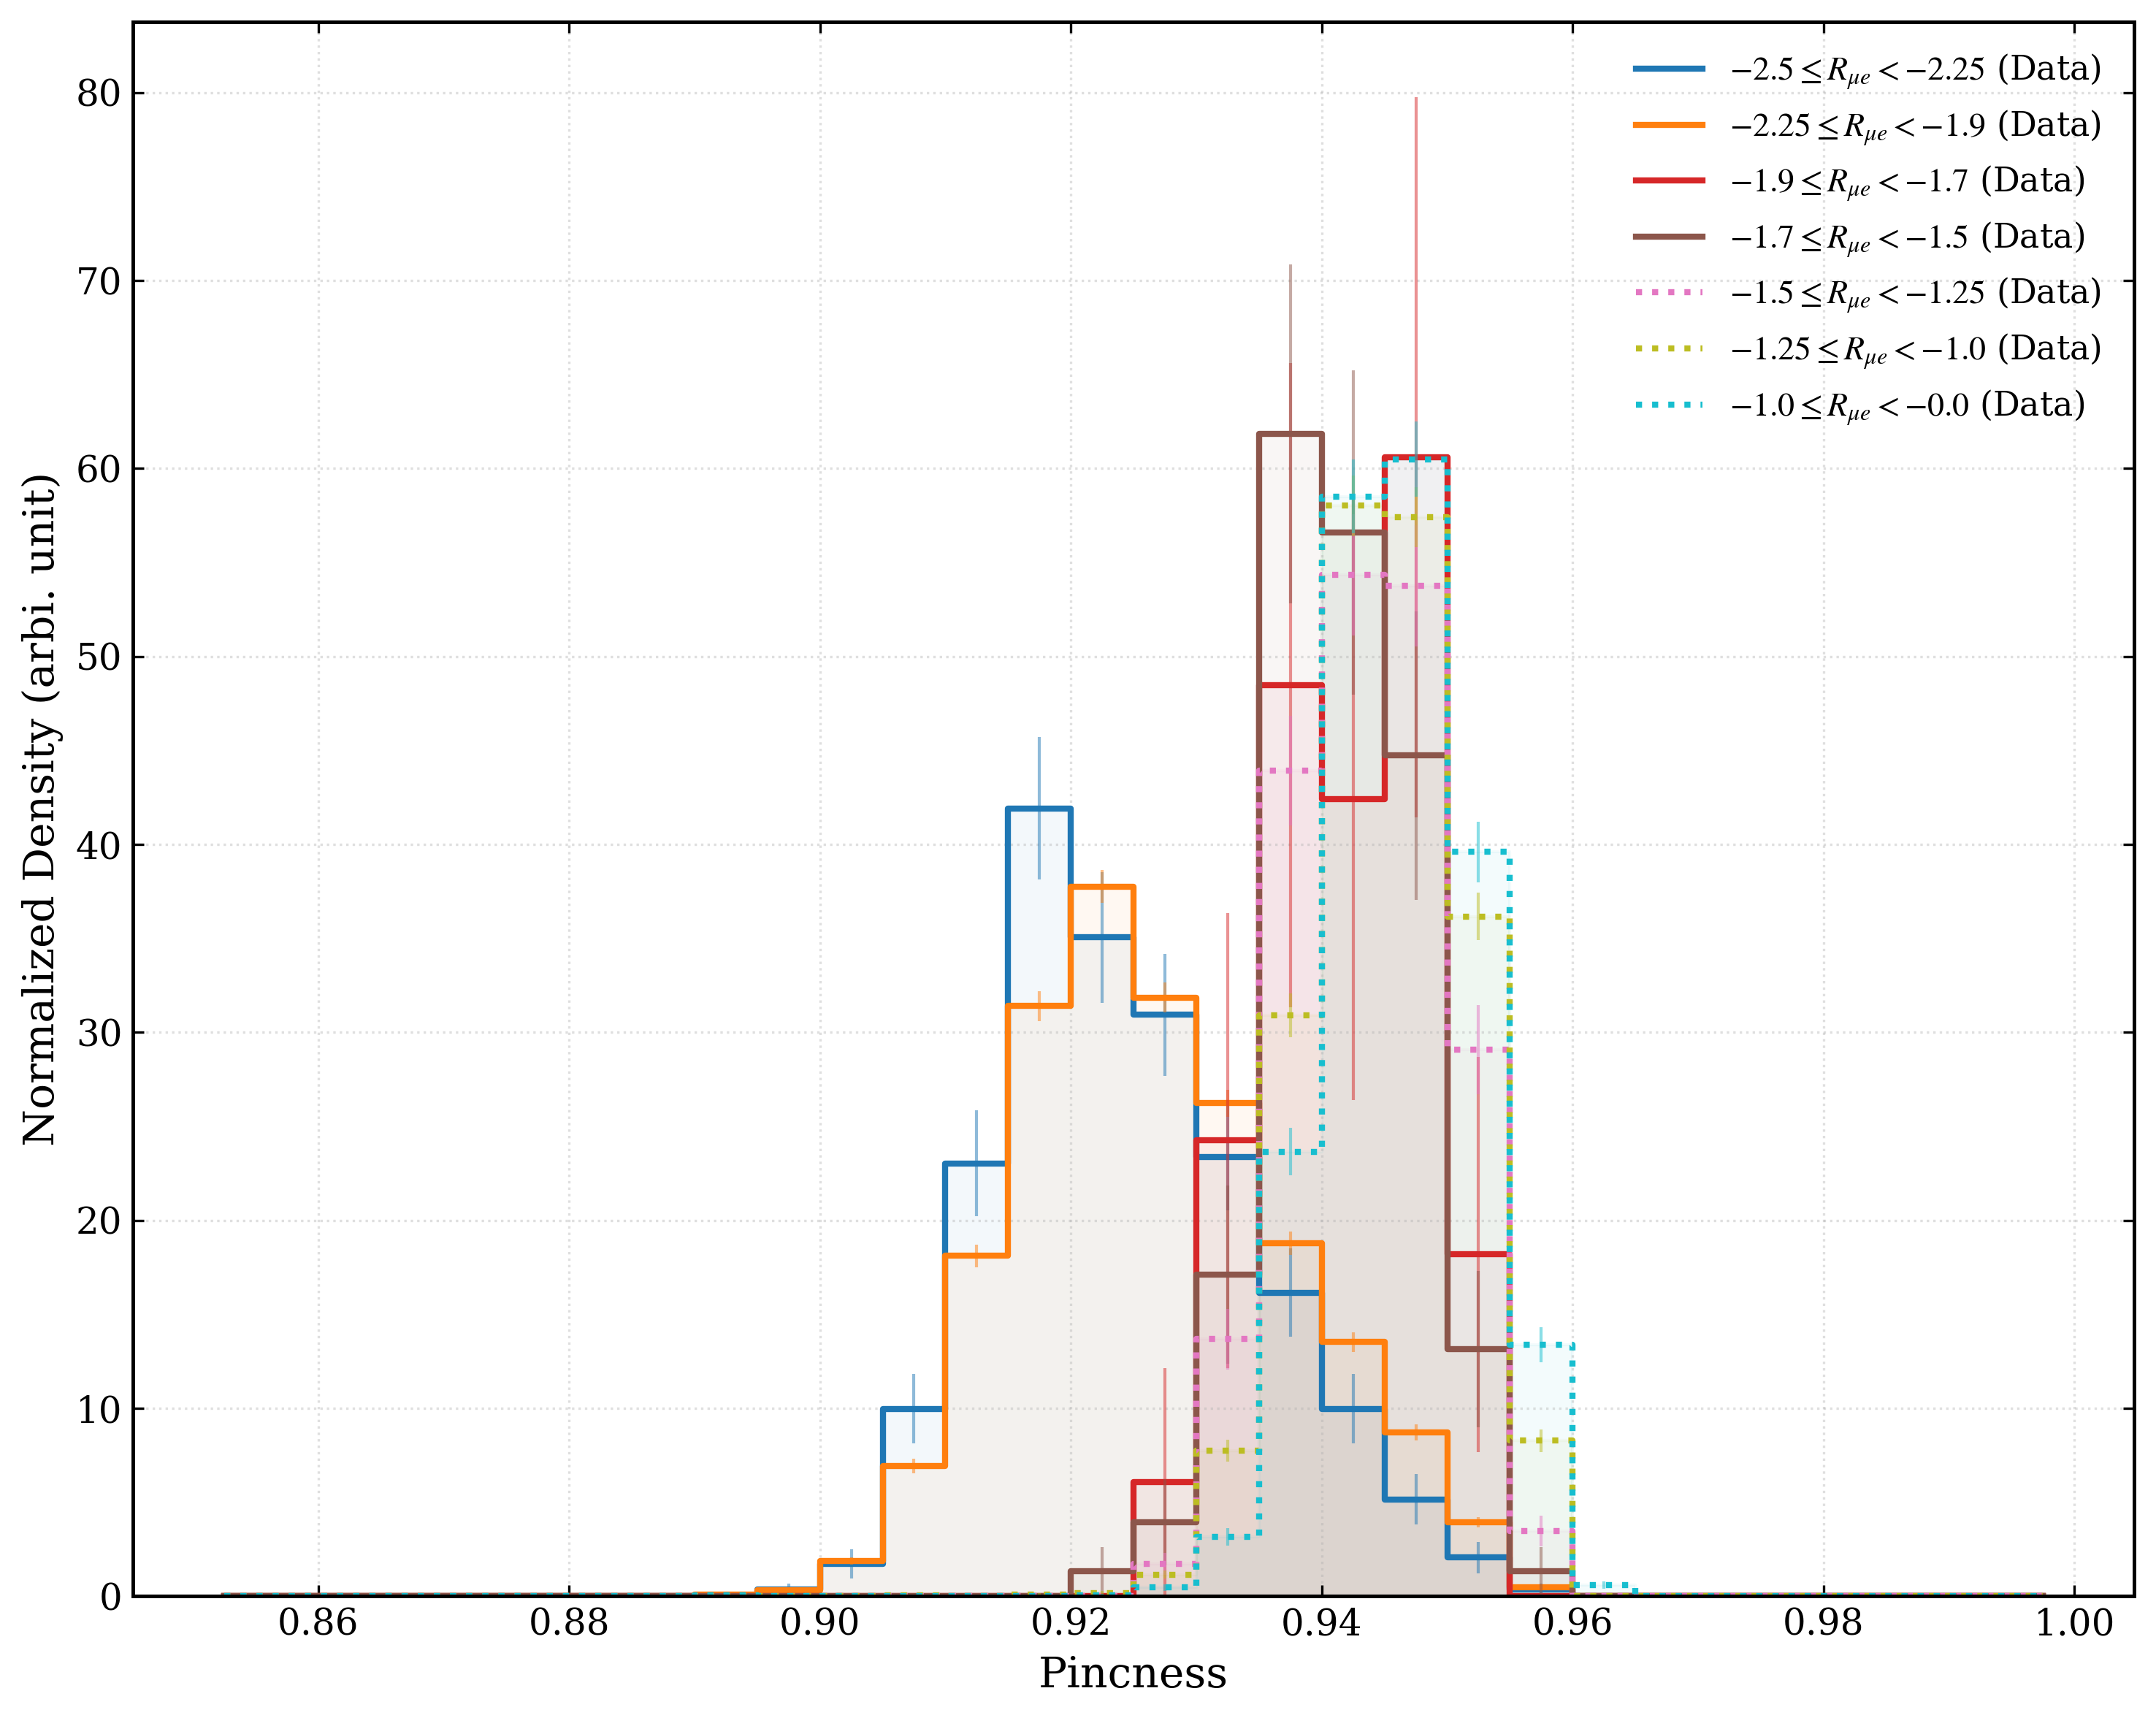

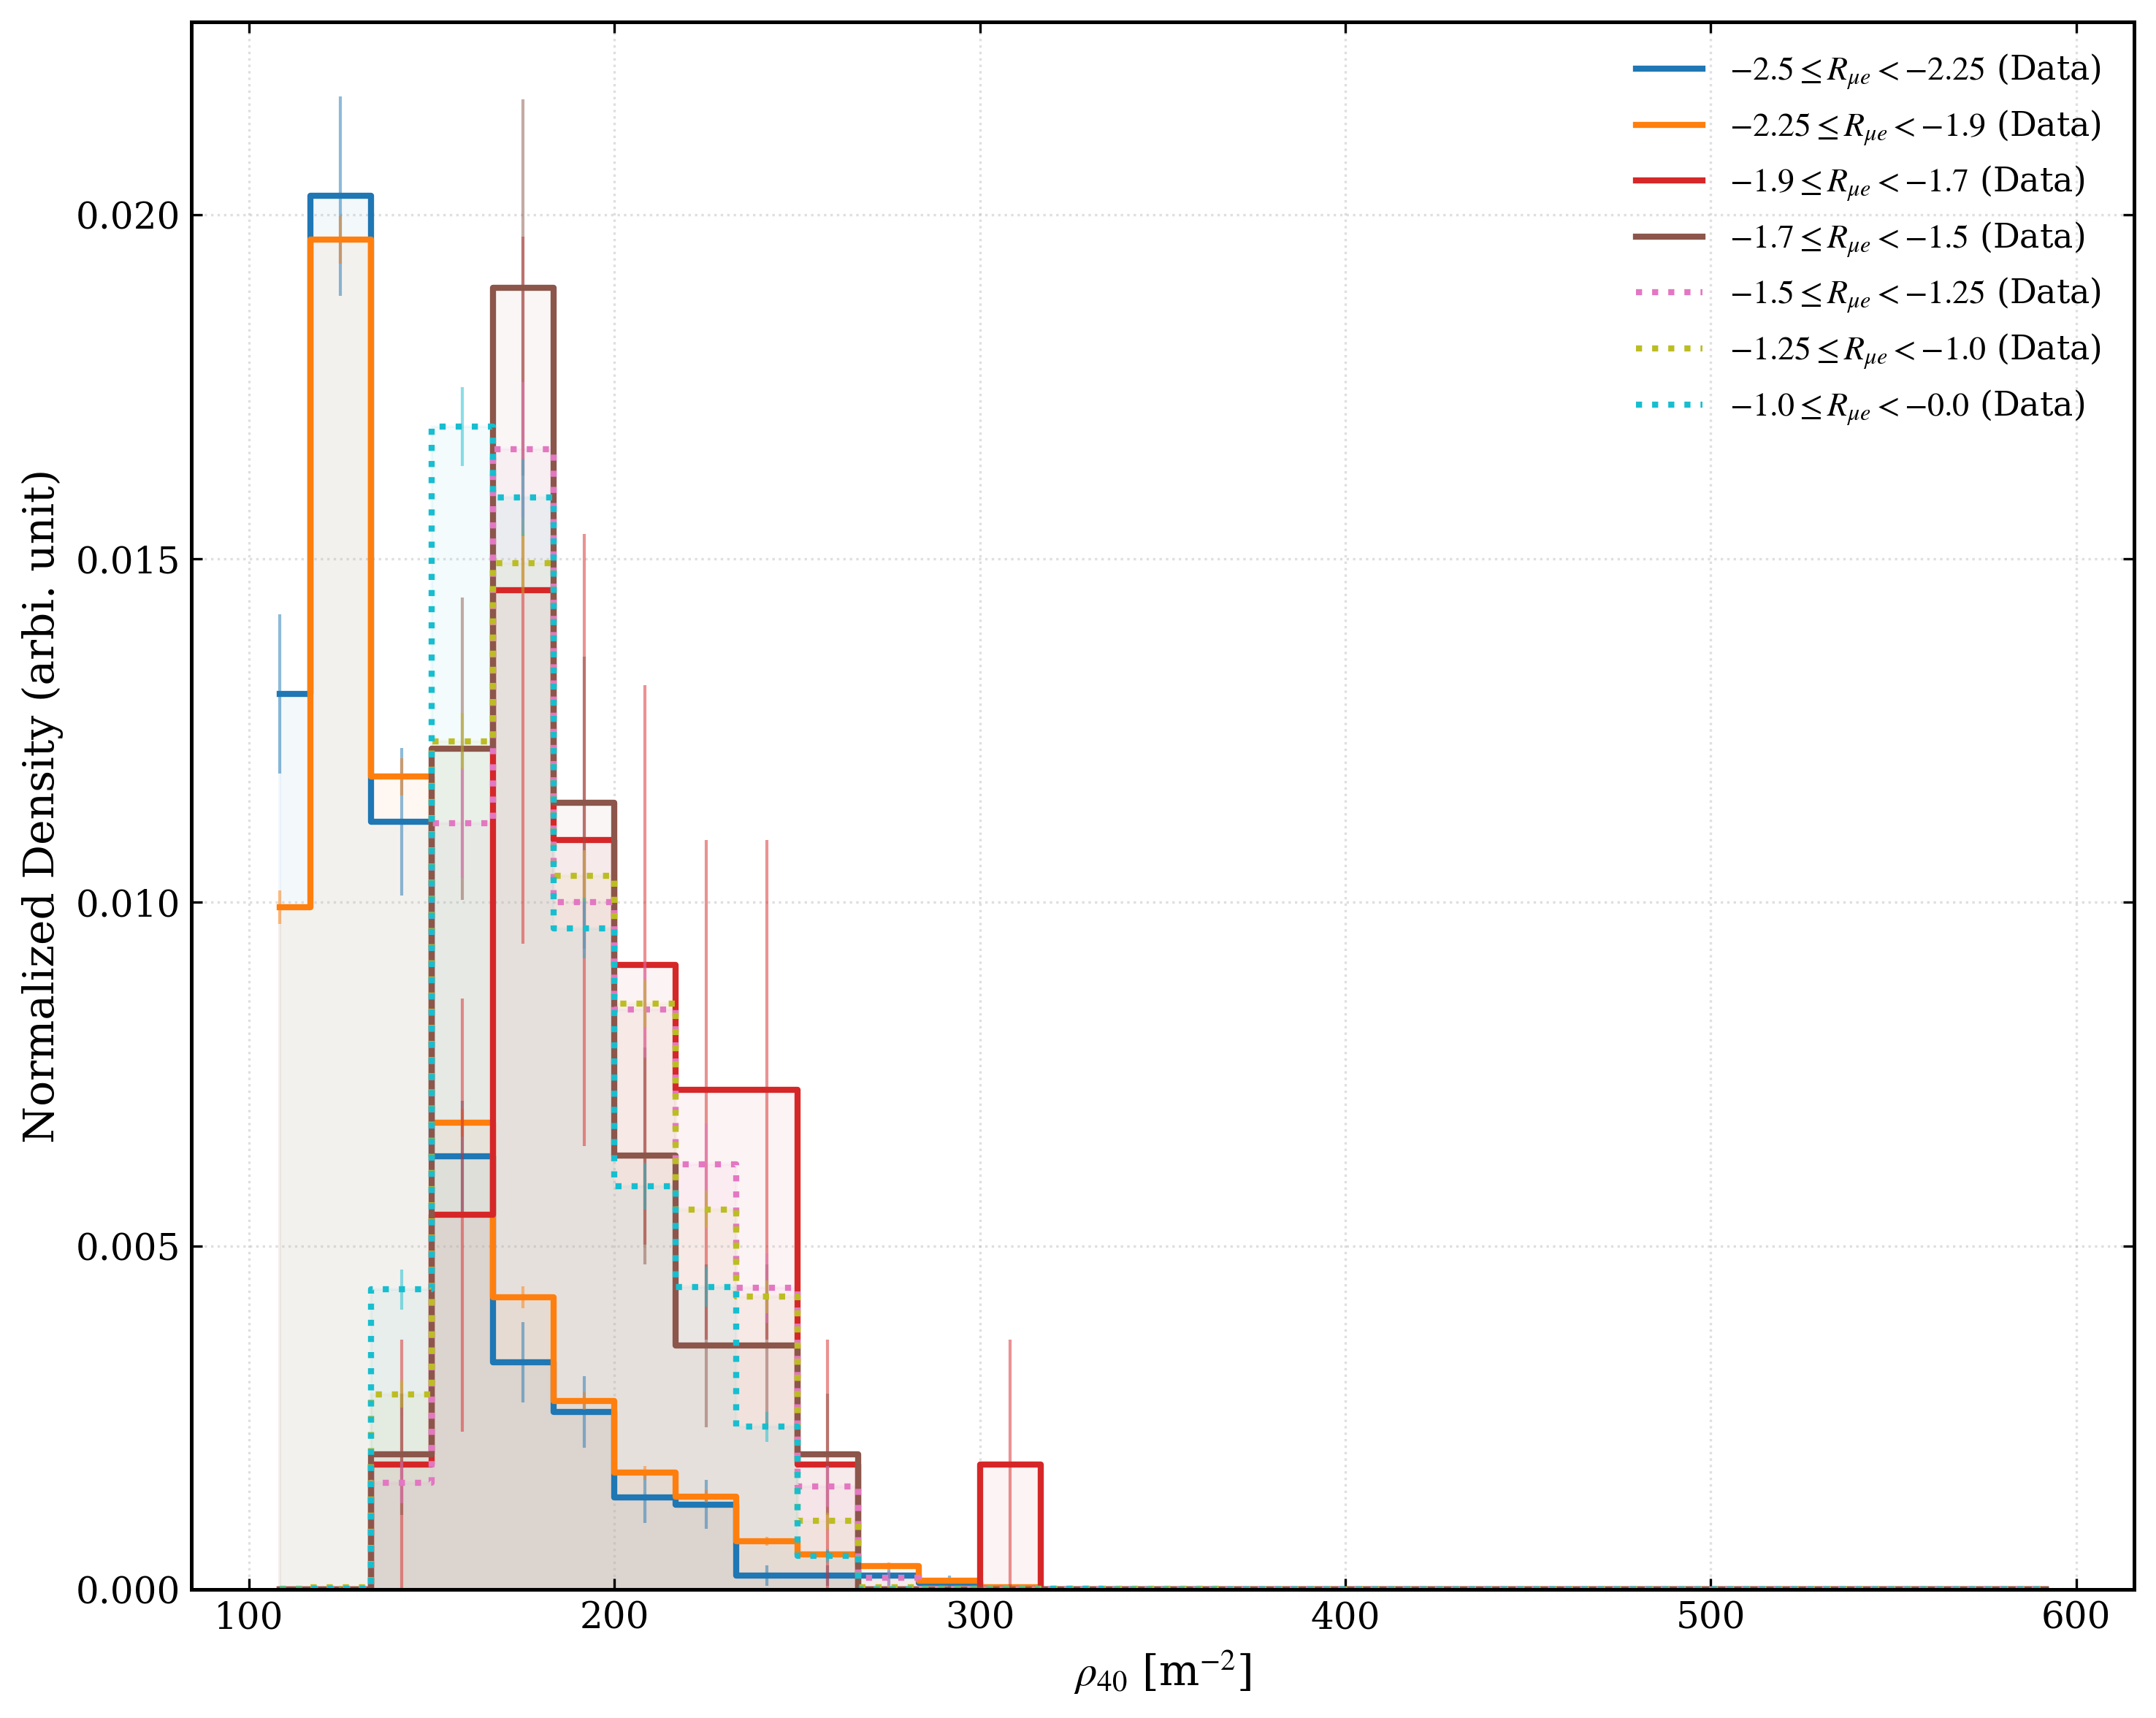

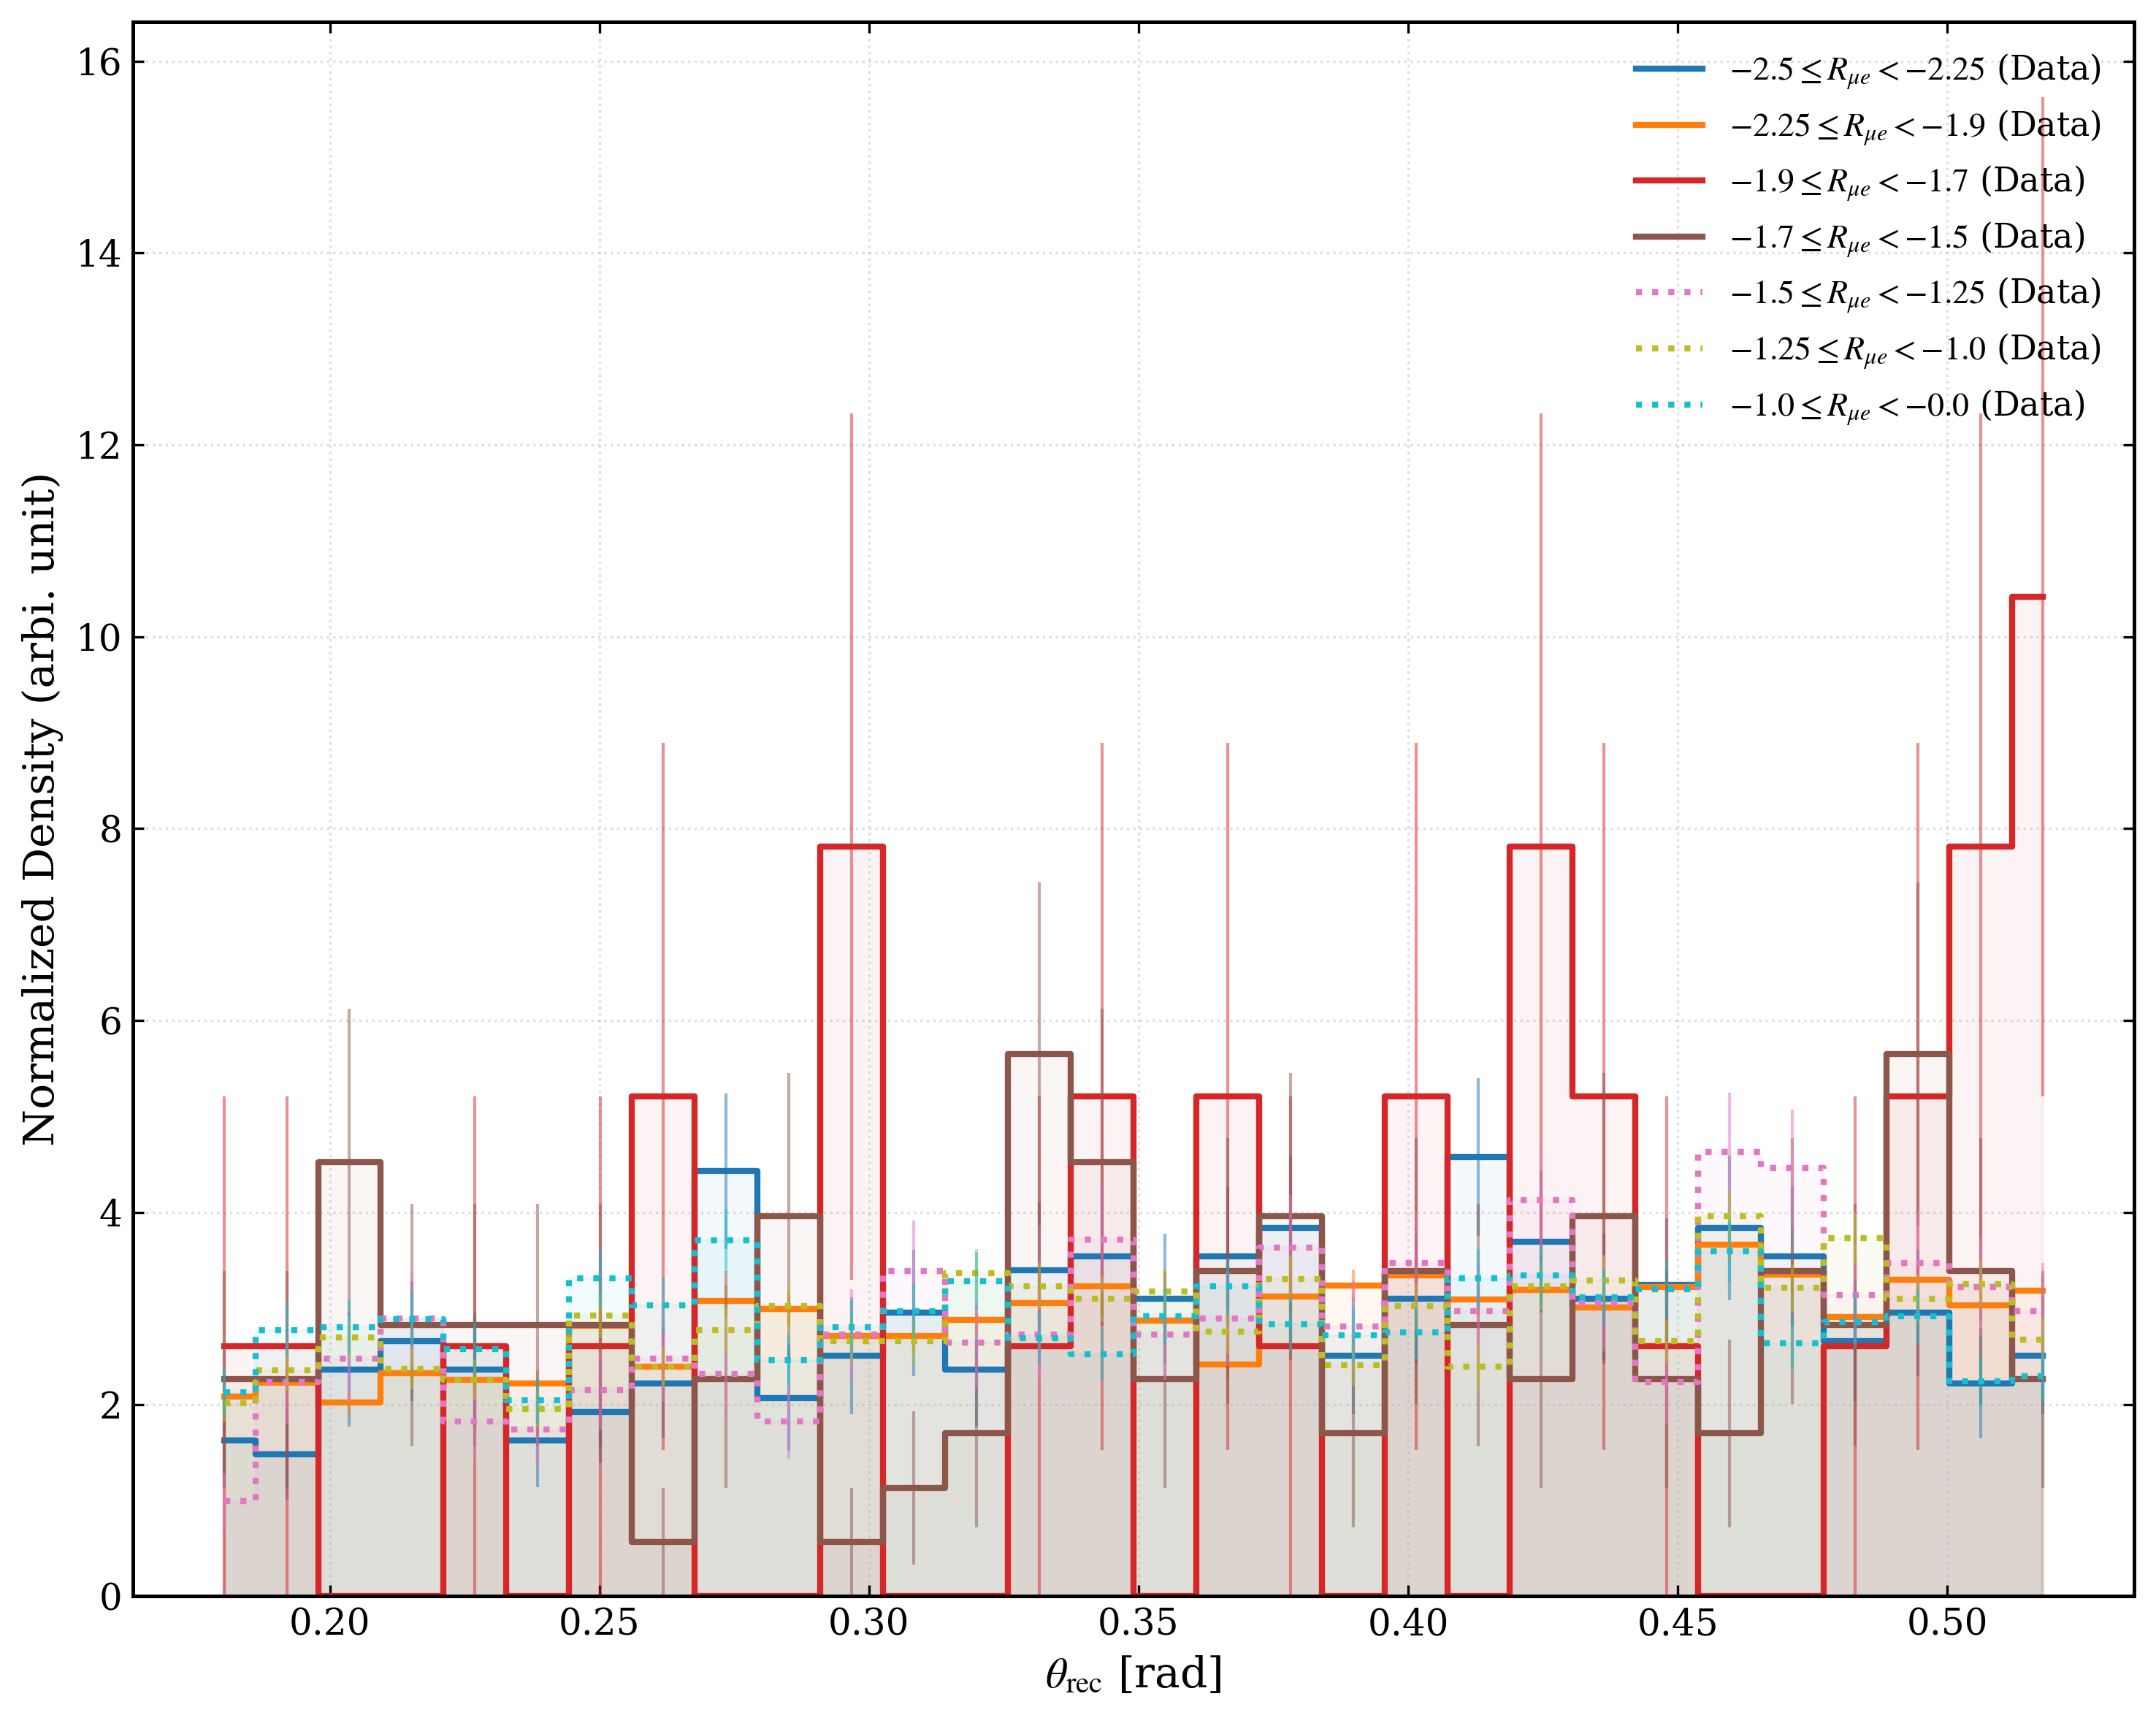

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_data_evolution_density(df_year, df_day, bins_config, var='Eage', figsize=(10, 8), filepath=None):
    # --- 1. 学术风格设置 (保持不变) ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 12,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "axes.linewidth": 1.2,
        "xtick.top": True,
        "ytick.right": True
    })

    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    # colors = plt.cm.magma(np.linspace(0, 0.9, len(bins_config)))
    colors = plt.cm.tab10(np.linspace(0, 1, len(bins_config)))
    # r'$\rho_{40}$ [m$^{-2}$]'
    var_info = {
        'Eage':  {'label': r'Shower Age ($s_{\mathrm{age}}$)', 'range': (0.8, 1.8), 'bins': 30},
        'pincness': {'label': 'Pincness', 'range': (0.85, 1), 'bins': 30},
        'rho40': {'label': r'$\rho_{40}$ [m$^{-2}$]', 'range': (100, 600), 'bins': 30},
        'rec_theta': {'label': r'$\theta_{\mathrm{rec}}$ [rad]', 'range': np.deg2rad((10, 30)), 'bins': 30},
    }
    cfg = var_info.get(var, {'label': var, 'range': None, 'bins': 30})

    for i, (r_low, r_high) in enumerate(bins_config):
        # --- 数据源选择 ---
        if r_high <= -1.9:
            source_label, df_source, linestyle = "Data", df_year, '-'
        elif r_high > -1.9 and r_high <= -1.5:
            source_label, df_source, linestyle = "Data", df_day, '-'
        else:
            source_label, df_source, linestyle = "Data", df_day, ':'
            
        # --- 2. 关键修复：强制转换数据类型 ---
        mask = (df_source['R_ue'] >= r_low) & (df_source['R_ue'] < r_high)
        
        # 使用 pd.to_numeric 过滤掉潜在的非数字并强制转为 float64
        selected_series = pd.to_numeric(df_source.loc[mask, var], errors='coerce').dropna()
        slice_data = selected_series.values.astype(float)
        
     
        
        N_events = len(slice_data)
        if N_events == 0: continue

        # --- 3. 计算直方图 ---
        hist, bin_edges = np.histogram(slice_data, bins=cfg['bins'], range=cfg['range'], density=True)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        
        # --- 4. 再次强制转换绘图数组类型 (防御性编程) ---
        hist = hist.astype(float)
        bin_centers = bin_centers.astype(float)

        raw_counts, _ = np.histogram(slice_data, bins=cfg['bins'], range=cfg['range'])
        valid_mask = raw_counts > 0
        yerr = np.zeros_like(hist)
        yerr[valid_mask] = hist[valid_mask] * (1.0 / np.sqrt(raw_counts[valid_mask]))

        # --- 5. 绘图 ---$N={N_events}$
        label_text = rf"${r_low} \leq R_{{\mu e}} < {r_high}$ ({source_label}) "
        
        ax.step(bin_centers, hist, where='mid', color=colors[i], linestyle=linestyle, linewidth=2, label=label_text)
        ax.errorbar(bin_centers[valid_mask], hist[valid_mask], yerr=yerr[valid_mask], 
                    fmt='none', ecolor=colors[i], elinewidth=1, capsize=0, alpha=0.5)
        
        # 这里之前报错，现在 hist 和 bin_centers 已经是纯粹的 float64 数组了
        ax.fill_between(bin_centers, hist, step='mid', color=colors[i], alpha=0.05)
    if var == 'Eage':
        ax.hist(mc_total[mc_total['R_ue'] < -1.5]['rec_Eage']+0.0263, bins=cfg['bins'], range=cfg['range'], density=True,
                histtype='stepfilled', alpha=0.5, color='gray', label='MC Total (Gaisser, Template region)')
        
    # --- 装饰 ---
    ax.set_xlabel(cfg['label'], fontsize=14)
    ax.set_ylabel("Normalized Density (arbi. unit)", fontsize=14)
    ax.legend(loc='best', frameon=False, fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    if filepath is not None:
        print(f"Saving figure to {filepath} ...")
        plt.savefig(filepath, bbox_inches='tight', pad_inches=0.1)
    plt.show()
print("Plotting Data Evolution...")
bins_to_compare = [
    # (-3.0, -2.75),  # 极低 Muon 区 (Signal-like / Light), 使用 Year Data
    # (-2.75, -2.5),  # 极低 Muon 区 (Signal-like / Light), 使用 Year Data
    (-2.5, -2.25),  # 过渡区/背景区, 使用 Day Data
    (-2.25, -1.9),  # 过渡区/背景区, 使用 Day Data
    (-1.9, -1.7),
    (-1.7, -1.5),  # 过渡区/背景区, 使用 Day Data
    (-1.5, -1.25),  # 如果需要，可以加更重的背景区
    (-1.25, -1.0),  # 如果需要，可以加更重的背景区
    (-1.0, -0.),
    # (-0.75, -0.5),
    # (-0.5, -0),  # 如果需要，可以加更重的背景区
]
plot_data_evolution_density(exp_Rue_df, one_day_df, bins_to_compare, var='Eage', filepath="/data/home/zzh/Filt_Event/Note_Writing/figures/1e11_data_Rue_Stability_Eage.pdf")
plot_data_evolution_density(exp_Rue_df, one_day_df, bins_to_compare, var='pincness')
plot_data_evolution_density(exp_Rue_df, one_day_df, bins_to_compare, var='rho40')
plot_data_evolution_density(exp_Rue_df, one_day_df, bins_to_compare, var='rec_theta')

